# Brooklyn Fitboxing: Predicting Member Churn

INTRODUCTION

-Brooklyn Fitboxing offers fitness classes where members can track their attendance and performance.

-Some members may stop attending or cancel their membership.
-This project uses machine learning to identify members who
may be at risk of leaving.

-The aim is to understand how attendance, performance and
membership behaviour are related to customer churn.

-The dataset used in this project is synthetic, meaning it was created to simulate member behaviour rather than collected
from actual Brooklyn Fitboxing customers.

# 1. Importing Libraries



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

# 2. Loading and Understanding the Dataset

In [3]:
df = pd.read_csv("/content/fitboxing_churn_dataset.csv")
print("Dataset shape:", df.shape)
print(df.head())
print("\nDataset information:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())

# Checking how many members stayed and how many left.
# This helps us understand the distribution of churn.

print("\nChurn distribution:")
print(df["churn"].value_counts())


Dataset shape: (1000, 11)
   member_id        full_name  age membership_type  months_as_member  \
0          1  Scarlett Martin   35         Premium                22   
1          2    Owen Anderson   23         Premium                21   
2          3      Lucas Lewis   35           Basic                22   
3          4    Daniel Miller   36           Basic                34   
4          5  Evelyn Thompson   39           Basic                30   

   avg_weekly_attendance  avg_points_per_session attendance_trend  \
0                   2.04                   95.35       decreasing   
1                   1.47                   64.22       increasing   
2                   2.54                   61.63       increasing   
3                   4.11                   67.27           stable   
4                   2.13                   68.77       increasing   

  points_trend  days_since_last_visit  churn  
0   increasing                     33      0  
1   decreasing                  

# 3. Exploratory Data Analysis

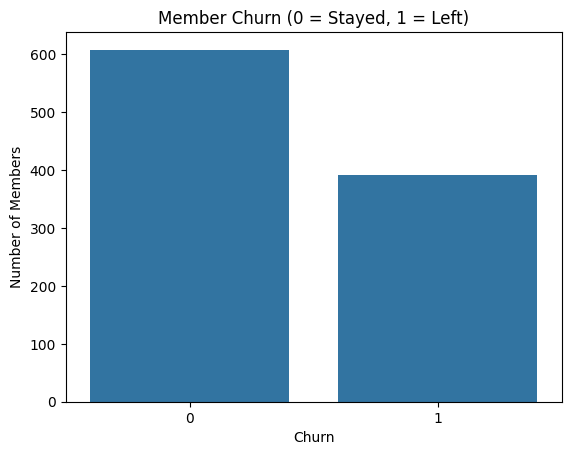

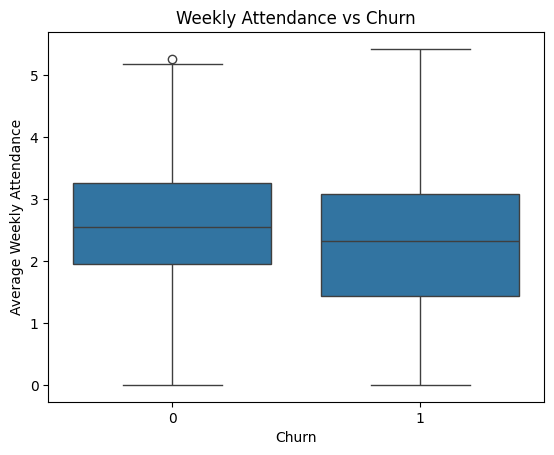

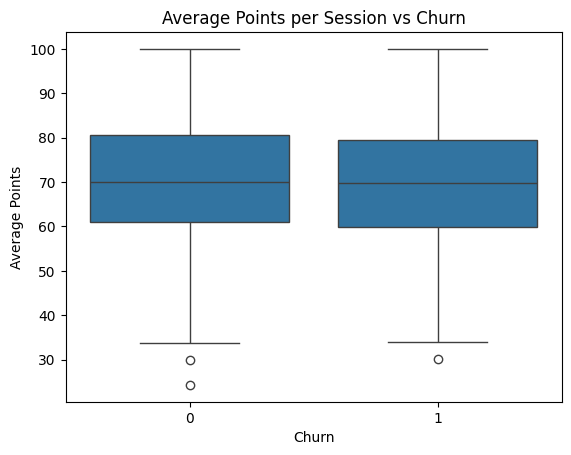

In [4]:
# Displaying the number of members who stayed or left.
sns.countplot(data=df, x="churn")
plt.title("Member Churn (0 = Stayed, 1 = Left)")
plt.xlabel("Churn")
plt.ylabel("Number of Members")
plt.show()

# Comparing weekly attendance of members who stayed and left.
# This helps us explore whether attendance is related to churn.

sns.boxplot(data=df, x="churn", y="avg_weekly_attendance")
plt.title("Weekly Attendance vs Churn")
plt.xlabel("Churn")
plt.ylabel("Average Weekly Attendance")
plt.show()

# Comparing average performance points between the two groups.
sns.boxplot(data=df, x="churn", y="avg_points_per_session")
plt.title("Average Points per Session vs Churn")
plt.xlabel("Churn")
plt.ylabel("Average Points")
plt.show()

# 4. Preparing the Data

In [6]:
# Before training, we separate the information used for prediction from the value we want to predict.
# Member names and IDs are removed because they identify individuals rather than describe their behaviour.

required_columns = [
    "member_id", "full_name", "age", "membership_type",
    "months_as_member", "avg_weekly_attendance",
    "avg_points_per_session", "attendance_trend",
    "points_trend", "days_since_last_visit", "churn"
]

# Checking that all expected columns are present.
missing_columns = [
    col for col in required_columns if col not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

# Removing rows where the target value is missing.
df = df.dropna(subset=["churn"]).copy()

# Confirming that churn is represented by 0 and 1.
if not set(df["churn"].unique()).issubset({0, 1}):
    raise ValueError("Churn must contain only 0 and 1.")

# X contains the features used to make predictions.
# y contains the actual churn values.

X = df.drop(columns=["member_id", "full_name", "churn"])
y = df["churn"].astype(int)

# Separate numerical and categorical features.
# Numerical values are measured quantities.
# Categorical values represent groups or labels.

numeric_cols = X.select_dtypes(
    include="number"
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Filling missing numerical values with the median and scale them to make their ranges more comparable.

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Filling missing categories with the most common value.
# One-hot encoding converts categories into numerical features that machine-learning models can use.

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combining both preprocessing steps into one pipeline.
# This ensures the same preparation is applied consistently.

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# 5. Spliting the Data into Training and Testing Sets

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 800
Testing rows: 200


# 6. Build the Machine-Learning Models

In [9]:
# We use two classification models to predict whether a member will stay or leave.
# Logistic Regression provides a simpler model for comparison.
# Random Forest combines multiple decision trees to identify patterns in the data.

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}


# 7. Train and Evaluate the Models


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       122
           1       0.63      0.68      0.65        78

    accuracy                           0.72       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.72      0.72      0.72       200



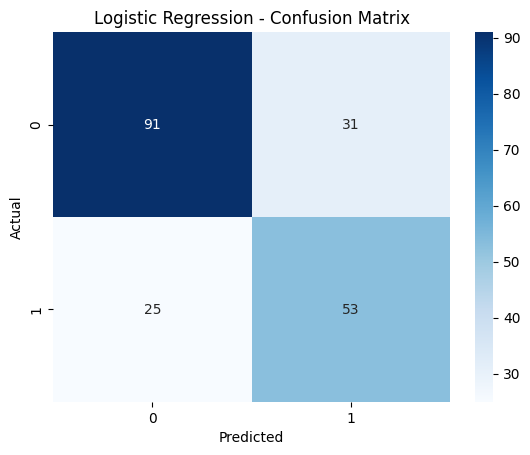


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       122
           1       0.69      0.56      0.62        78

    accuracy                           0.73       200
   macro avg       0.72      0.70      0.71       200
weighted avg       0.73      0.73      0.72       200



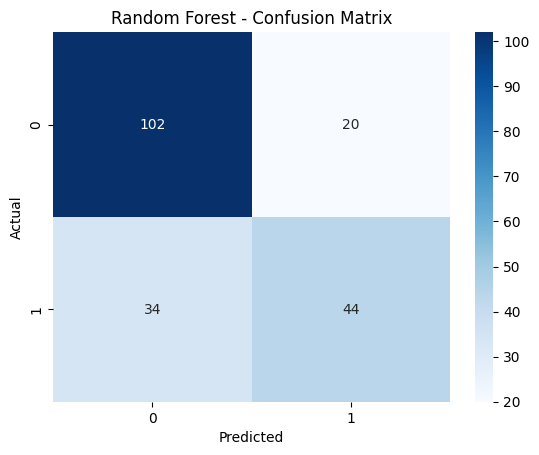


Model comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression      0.72      0.631   0.679     0.654    0.799
Random Forest            0.73      0.688   0.564     0.620    0.812


In [10]:
results = {}
scores = []

for name, model in models.items():

    # Combine data preparation and model training.
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train the model.
    pipeline.fit(X_train, y_train)

    # Predict churn and estimate churn probabilities.
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    # Store the evaluation scores for comparison.
    scores.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

    results[name] = pipeline

    print(f"\n--- {name} ---")

    # Show a detailed breakdown of the predictions.
    print(classification_report(
        y_test, predictions, zero_division=0
    ))

    # The confusion matrix shows correct and incorrect
    # predictions for members who stayed and members who left.
    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# Compare both models using their evaluation scores.
# The results help us understand their different strengths.

results_table = pd.DataFrame(scores).set_index("Model")

print("\nModel comparison:")
print(results_table.round(3))


# 8. Feature Importance


Top 10 important features:
                             Feature  Importance
4         num__days_since_last_visit    0.276370
2         num__avg_weekly_attendance    0.193748
3        num__avg_points_per_session    0.145108
1              num__months_as_member    0.117730
0                           num__age    0.116904
8   cat__attendance_trend_decreasing    0.023776
11      cat__points_trend_decreasing    0.017473
10      cat__attendance_trend_stable    0.016254
5         cat__membership_type_Basic    0.016151
6       cat__membership_type_Premium    0.015911


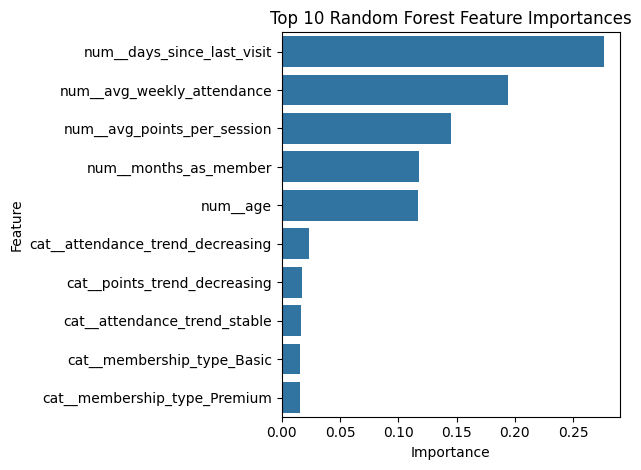

In [11]:
rf_pipeline = results["Random Forest"]

feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_pipeline.named_steps["model"].feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Display the ten features with the highest importance.
print("\nTop 10 important features:")
print(importance_df.head(10))

# Visualise the feature importance results.
sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# 9. Estimate Churn Risk

In [12]:
risk_df = X_test.copy()

risk_df["actual_churn"] = y_test
risk_df["churn_probability"] = (
    rf_pipeline.predict_proba(X_test)[:, 1]
)

# Showing the members with the highest estimated churn risk.
risk_df = risk_df.sort_values(
    "churn_probability",
    ascending=False
)

print("\nTop 10 members with highest estimated churn risk:")
print(risk_df.head(10))

# Save the risk scores so they can be reviewed later.
risk_df.to_csv(
    "fitboxing_churn_risk_scores.csv",
    index=False
)

print("\nChurn risk results saved successfully.")


Top 10 members with highest estimated churn risk:
     age membership_type  months_as_member  avg_weekly_attendance  \
404   34       Unlimited                14                   0.69   
221   26         Premium                19                   1.14   
598   46       Unlimited                21                   1.49   
539   38       Unlimited                28                   1.69   
666   26           Basic                27                   2.67   
903   33         Premium                14                   1.25   
1     23         Premium                21                   1.47   
381   39         Premium                11                   1.69   
662   48         Premium                 8                   1.06   
377   55           Basic                25                   0.48   

     avg_points_per_session attendance_trend points_trend  \
404                   83.43       decreasing       stable   
221                   70.60       decreasing       stable   
598   

# 10. Conclusion and Future Work

CONCLUSION

-This project used machine learning to explore member churn at Brooklyn Fitboxing. Attendance, performance, membership details and recent visit behaviour were used as predictors.

-Logistic Regression and Random Forest were trained and evaluated using a separate test set. Their evaluation scores can be compared to understand how well each model identifies members who may leave.

-The churn risk estimates could help the club identify members who may benefit from a check-in or additional support.

-However, the dataset is synthetic, so these results do notnconfirm how accurately the models would predict churn using real customer data.

FUTURE WORK

Future improvements could include:
 - Testing the model using real member data.
 - Adding payment history and member feedback.
 - Testing predictions on data from a later time period.
 - Creating a dashboard for staff to review churn risk.

Overall, this project demonstrates how data analysis and machine learning can be used to investigate customer churn and support member-retention planning.